# Lab 2 — Latent Dynamics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab02_latent_dynamics/notebook.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 2**

Labs 0–1 used a hand-written transition function and a hand-designed state. Real agents get neither — just pixels. The modern answer (World Models, Dreamer, and friends) is to **learn** the whole pipeline:

```
image x_t ──Encoder──▶ z_t ──Dynamics(z_t, a_t)──▶ ẑ_{t+1} ──Decoder──▶ predicted image x̂_{t+1}
```

In this lab you will train exactly this loop at toy scale: a convolutional encoder compresses 64×64 images of a moving ball into a 16-dimensional latent `z`, an MLP learns the action-conditioned transition in latent space, and a convolutional decoder turns predicted latents back into images. The finale: an **open-loop rollout** — give the model one initial frame and a sequence of actions, and let it dream the future. You will watch its error compound with every step, which is precisely the problem that RSSM-style posterior correction solves.

## Setup

**Why:** PyTorch is the only heavy dependency (CPU build is fine — Colab already ships it). `imageio` is used for the rollout GIF. Everything runs in a few minutes on CPU.

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg, name in [("torch", "torch"), ("imageio", "imageio")]:
    ensure(pkg, name)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import imageio.v2 as imageio
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

%matplotlib inline
os.makedirs("assets", exist_ok=True)
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device: cpu")

torch 2.8.0 | device: cpu


## 1. Data: sequences of a moving ball

**Why:** a dynamics model needs *transitions*, not isolated images — triples `(x_t, a_t, x_{t+1})`. We reuse the Lab-0 physics (force actions, friction, wall bounces) to generate ~2000 frames: 100 episodes of 20 steps each. Because we wrote the simulator, we know the true state exists and the task is perfectly learnable — a clean testbed before anyone touches real video.

frames: (2000, 64, 64), actions: (2000, 2)


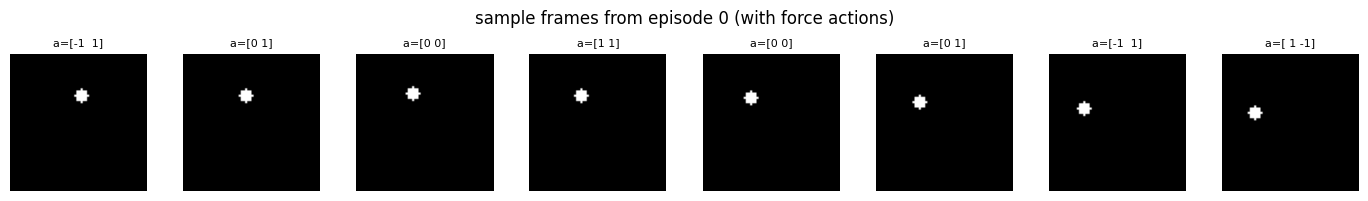

In [2]:
SIZE, N_EP, EP_LEN = 64, 100, 20
DT, FRICTION, BOUNCE, FORCE = 0.1, 0.95, 0.9, 2.0

def render_ball(x, y, size=SIZE):
    img = np.zeros((size, size), dtype=np.float32)
    px = int(np.clip(x, 0, 1) * (size - 1))
    py = int(np.clip(y, 0, 1) * (size - 1))
    yy, xx = np.mgrid[0:size, 0:size]
    img[(xx - px) ** 2 + (yy - py) ** 2 <= 3 ** 2] = 1.0
    return img

def simulate_dataset(n_ep=N_EP, ep_len=EP_LEN, seed=0):
    rng = np.random.default_rng(seed)
    frames, actions, ep_ids = [], [], []
    for ep in range(n_ep):
        x, y = rng.uniform(0.15, 0.85, size=2)
        vx, vy = rng.uniform(-0.5, 0.5, size=2)
        for t in range(ep_len):
            a = rng.integers(-1, 2, size=2).astype(np.float32)
            vx = (vx + FORCE * a[0] * DT) * FRICTION
            vy = (vy + FORCE * a[1] * DT) * FRICTION
            x, y = x + vx * DT, y + vy * DT
            if x < 0: x, vx = -x, -vx * BOUNCE
            if x > 1: x, vx = 2 - x, -vx * BOUNCE
            if y < 0: y, vy = -y, -vy * BOUNCE
            if y > 1: y, vy = 2 - y, -vy * BOUNCE
            frames.append(render_ball(x, y))
            actions.append(a)
            ep_ids.append(ep)
    return np.stack(frames), np.stack(actions), np.array(ep_ids)

frames_np, actions_np, ep_ids = simulate_dataset()
print(f"frames: {frames_np.shape}, actions: {actions_np.shape}")

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(frames_np[i], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"a={actions_np[i].astype(int)}", fontsize=8)
    ax.axis("off")
plt.suptitle("sample frames from episode 0 (with force actions)")
plt.tight_layout()
plt.show()

## 2. Model: Encoder → Dynamics → Decoder

**Why this architecture:** images are high-dimensional and redundant; physics is low-dimensional. The encoder's job is to throw away everything except what matters for prediction (here: roughly the ball's position and velocity). The dynamics MLP then only has to learn a small, nearly-linear map `(z_t, a_t) → z_{t+1}` — much easier than predicting 4096 pixels directly. The decoder exists mainly to *shape* the latent space: the reconstruction loss forces `z` to retain everything needed to draw the image.

- **Encoder:** 3 strided convs (64→32→16→8) + MLP → `z ∈ R^16`.
- **Dynamics:** 2-hidden-layer MLP with a residual head: `ẑ_{t+1} = z_t + f(z_t, a_t)` (residual = small world changes are easy to learn).
- **Decoder:** mirrored transposed convs. Note the decoder outputs **logits**, not probabilities — we apply `sigmoid` only for display. Training with `BCEWithLogitsLoss` on raw logits is numerically better behaved than squeezing through a sigmoid first.

In [3]:
Z_DIM, A_DIM = 16, 2

class Encoder(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 4, 2, 1), nn.ReLU(),   # 64 -> 32
            nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU(),  # 32 -> 16
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),  # 16 -> 8
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, z_dim),
        )

    def forward(self, x):
        return self.net(x)

class Dynamics(nn.Module):
    def __init__(self, z_dim=Z_DIM, a_dim=A_DIM, h=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim + a_dim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, z_dim),
        )

    def forward(self, z, a):
        return z + self.net(torch.cat([z, a], dim=-1))  # residual transition

class Decoder(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(z_dim, 128), nn.ReLU(), nn.Linear(128, 64 * 8 * 8), nn.ReLU())
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),  # 8 -> 16
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(),  # 16 -> 32
            nn.ConvTranspose2d(16, 1, 4, 2, 1),              # 32 -> 64, raw logits
        )

    def forward(self, z):
        return self.deconv(self.fc(z).view(-1, 64, 8, 8))  # logits; sigmoid for display only

enc, dyn, dec = Encoder(), Dynamics(), Decoder()
n_params = sum(p.numel() for m in (enc, dyn, dec) for p in m.parameters())
print(f"parameters: {n_params:,}  (tiny — CPU-friendly)")

parameters: 1,160,641  (tiny — CPU-friendly)


## 3. Training: reconstruction + one-step latent prediction

**Why these two losses:**

- **Reconstruction**, as binary cross-entropy on the decoder logits — shapes the latent space so that `z` actually encodes the ball's configuration. We use `pos_weight=10` because the ball occupies only ~0.7% of the pixels: without it, the loss is dominated by easy black background and the model can stall at "predict darkness everywhere".
- **One-step latent prediction** `||dyn(sg(z_t), a_t) − sg(z_{t+1})||²` — makes the dynamics model useful *in latent space*, where rollouts will run. `sg` = stop-gradient, applied on **both** sides: the encoder's features are shaped purely by reconstruction, and the dynamics learns to track them. If we let this loss backpropagate into the encoder, it can earn a trivial zero by making `z` temporally constant — a degenerate collapse that destroys reconstruction. (Try removing the `detach()`s in Exercise 2 to see this failure mode!)

The printed latent-prediction loss is normalized by the target variance, so it reads as a *fraction of unexplained variance* (0 = perfect). Together these two losses are the toy-scale essence of the PlaNet/Dreamer objectives (minus the probabilistic bells and whistles — Lab 3 territory).

1900 valid transitions


step  200/1000  recon-BCE 0.2530  latent-pred 0.0000


step  400/1000  recon-BCE 0.0173  latent-pred 0.0968


step  600/1000  recon-BCE 0.0126  latent-pred 0.0959


step  800/1000  recon-BCE 0.0083  latent-pred 0.0826


step 1000/1000  recon-BCE 0.0079  latent-pred 0.0763
trained in 56.6s on CPU


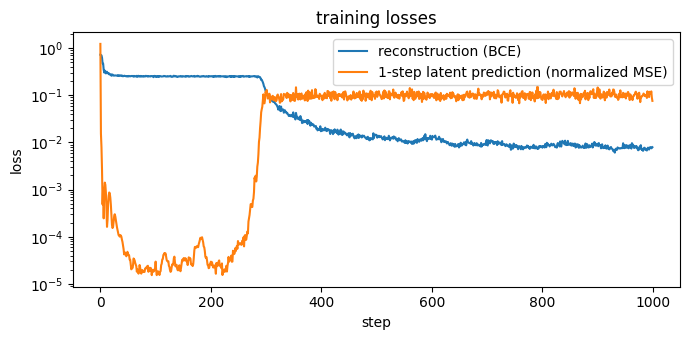

In [4]:
imgs = torch.from_numpy(frames_np).unsqueeze(1)          # (2000, 1, 64, 64)
acts = torch.from_numpy(actions_np)                      # (2000, 2)
# valid transitions are consecutive frames within the same episode
valid = np.where(ep_ids[:-1] == ep_ids[1:])[0]
print(f"{len(valid)} valid transitions")

params = list(enc.parameters()) + list(dyn.parameters()) + list(dec.parameters())
opt = torch.optim.Adam(params, lr=3e-3)
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(10.0))  # ball pixels are rare positives
mse = nn.MSELoss()

BATCH, STEPS = 64, 1000
rng = np.random.default_rng(0)
losses = []
t0 = time.time()
for step in range(STEPS):
    idx = torch.from_numpy(rng.choice(valid, size=BATCH, replace=False))
    x0, x1, a = imgs[idx], imgs[idx + 1], acts[idx]

    z0 = enc(x0)
    z1_target = enc(x1).detach()                 # stop-gradient target
    z1_pred = dyn(z0.detach(), a)                # stop-gradient input: enc is shaped by recon only

    loss_recon = bce(dec(z0), x0)
    loss_pred = mse(z1_pred, z1_target)
    loss = loss_recon + loss_pred

    opt.zero_grad()
    loss.backward()
    opt.step()
    pred_norm = loss_pred.item() / (z1_target.var().item() + 1e-8)  # fraction of unexplained variance
    losses.append((loss_recon.item(), pred_norm))
    if (step + 1) % 200 == 0:
        print(f"step {step+1:4d}/{STEPS}  recon-BCE {loss_recon.item():.4f}  latent-pred {pred_norm:.4f}")

print(f"trained in {time.time() - t0:.1f}s on CPU")

losses = np.array(losses)
plt.figure(figsize=(7, 3.5))
plt.plot(losses[:, 0], label="reconstruction (BCE)")
plt.plot(losses[:, 1], label="1-step latent prediction (normalized MSE)")
plt.xlabel("step")
plt.ylabel("loss")
plt.yscale("log")
plt.title("training losses")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Does the model see the world? Reconstructions

**Why check reconstruction first:** if the autoencoder cannot even *copy* the current frame through `z`, nothing downstream can work. A sharp, well-localized blob means the 16-dim latent carries the ball's position — enough for the dynamics to do its job. (Remember: the decoder outputs logits, so we apply `sigmoid` for display.)

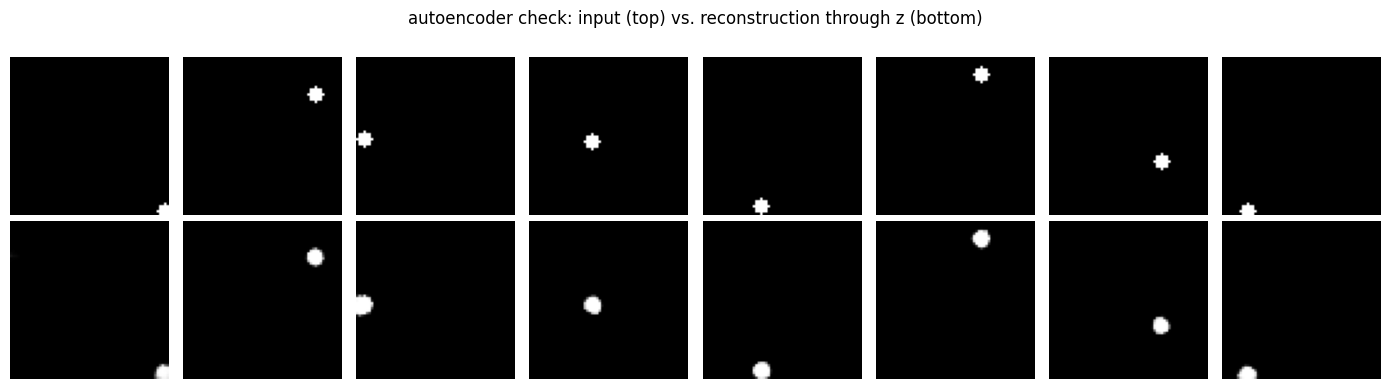

In [5]:
enc.eval(); dyn.eval(); dec.eval()
with torch.no_grad():
    idx = torch.from_numpy(rng.choice(len(imgs), size=8, replace=False))
    recon = torch.sigmoid(dec(enc(imgs[idx])))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for j in range(8):
    axes[0, j].imshow(imgs[idx][j, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, j].imshow(recon[j, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, j].axis("off"); axes[1, j].axis("off")
axes[0, 0].set_ylabel("input", fontsize=10)
axes[1, 0].set_ylabel("recon", fontsize=10)
plt.suptitle("autoencoder check: input (top) vs. reconstruction through z (bottom)")
plt.tight_layout()
plt.show()

## 5. One-step prediction

**Why:** before dreaming many steps ahead, verify the atomic operation: `dyn(z_t, a_t)` decoded back into an image should look like `x_{t+1}`. This is the learned analogue of the Kalman filter's *predict* step — the same `(state, action) → next state` idea, now fully learned from pixels.

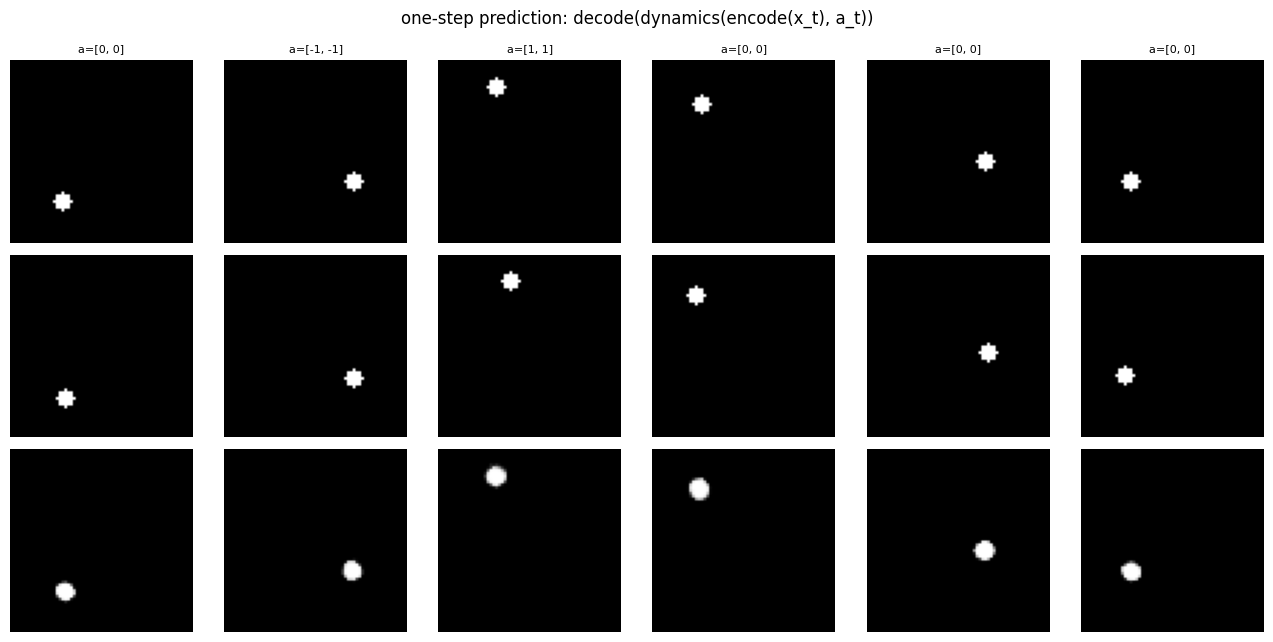

In [6]:
with torch.no_grad():
    idx = torch.from_numpy(rng.choice(valid, size=6, replace=False))
    z1_pred = dyn(enc(imgs[idx]), acts[idx])
    x1_pred = torch.sigmoid(dec(z1_pred))

fig, axes = plt.subplots(3, 6, figsize=(13, 6.5))
for j in range(6):
    axes[0, j].imshow(imgs[idx][j, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, j].imshow(imgs[idx + 1][j, 0], cmap="gray", vmin=0, vmax=1)
    axes[2, j].imshow(x1_pred[j, 0], cmap="gray", vmin=0, vmax=1)
    for ax in axes[:, j]:
        ax.axis("off")
    axes[0, j].set_title(f"a={acts[idx][j].int().tolist()}", fontsize=8)
axes[0, 0].set_ylabel("x_t", fontsize=10)
axes[1, 0].set_ylabel("true x_{t+1}", fontsize=10)
axes[2, 0].set_ylabel("predicted", fontsize=10)
plt.suptitle("one-step prediction: decode(dynamics(encode(x_t), a_t))")
plt.tight_layout()
plt.show()

## 6. Open-loop rollout: dreaming the future

**Why this is the whole point of a world model:** give the model **one initial frame** and a **sequence of future actions**, and let it predict the entire trajectory *in latent space*, never seeing a real image again:

$$z_0 = \mathrm{enc}(x_0), \qquad z_{k+1} = \mathrm{dyn}(z_k, a_k), \qquad \hat{x}_k = \mathrm{dec}(z_k)$$

This is what "planning in imagination" means in Dreamer-style agents. The montage below puts the dream (bottom row of each pair) next to the ground truth (top row).

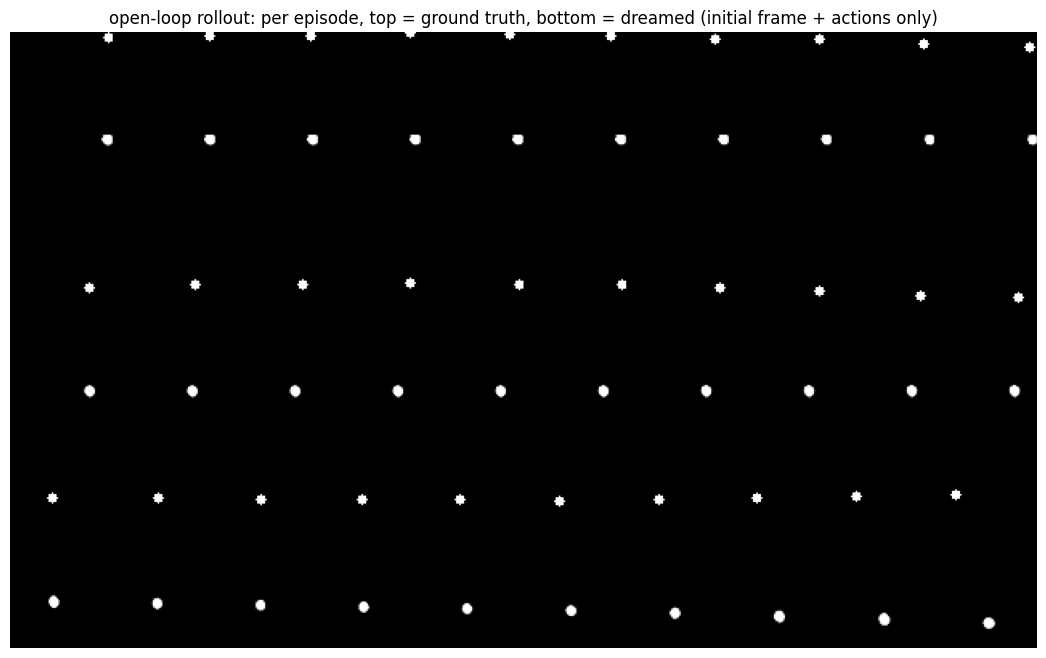

saved assets/openloop_grid.png and assets/openloop_rollout.gif


In [7]:
ROLLOUT = 10

def open_loop(start_idx, horizon=ROLLOUT):
    # initial frame + true future actions -> dreamed frames
    with torch.no_grad():
        z = enc(imgs[start_idx:start_idx + 1])
        dreamed = []
        for k in range(horizon):
            z = dyn(z, acts[start_idx + k:start_idx + k + 1])
            dreamed.append(torch.sigmoid(dec(z))[0, 0].numpy())
    gt = [frames_np[start_idx + k] for k in range(horizon)]
    return gt, dreamed

starts = rng.choice(valid[valid + ROLLOUT < len(imgs)], size=3, replace=False)
rows = []
for s in starts:
    gt, dreamed = open_loop(int(s))
    rows.append(np.concatenate(gt, axis=1))
    rows.append(np.concatenate(dreamed, axis=1))
grid = np.concatenate(rows, axis=0)

plt.figure(figsize=(15, 8))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("open-loop rollout: per episode, top = ground truth, bottom = dreamed (initial frame + actions only)")
plt.savefig("assets/openloop_grid.png", dpi=110, bbox_inches="tight")
plt.show()

# save one episode as an animated side-by-side GIF
gt, dreamed = open_loop(int(starts[0]))
side_by_side = [np.concatenate([g, d], axis=1) for g, d in zip(gt, dreamed)]
imageio.mimsave("assets/openloop_rollout.gif",
                [(f * 255).astype(np.uint8) for f in side_by_side], duration=0.25)
print("saved assets/openloop_grid.png and assets/openloop_rollout.gif")

fig = plt.figure(figsize=(4, 2))
plt.axis("off")
_im = plt.imshow(side_by_side[0], cmap="gray", vmin=0, vmax=1)
def _upd(i):
    _im.set_data(side_by_side[i])
    return [_im]
_anim = FuncAnimation(fig, _upd, frames=len(side_by_side), interval=250, blit=True)
plt.close(fig)
HTML(_anim.to_jshtml())

## 7. Compounding error: the drift curve

**Why quantify it:** every dreamed step feeds the model's *own* prediction back as input, so small errors get amplified — the same phenomenon as the Kalman filter's growing covariance in the predict-only case, except now nonlinear and learned. Measuring MSE against ground truth as a function of horizon shows exactly how fast the dream departs from reality. (It eventually saturates: the bouncing ball "mixes" — after enough steps, even the true dynamics forgets the initial condition, so error levels off at the scale of pure guessing.)

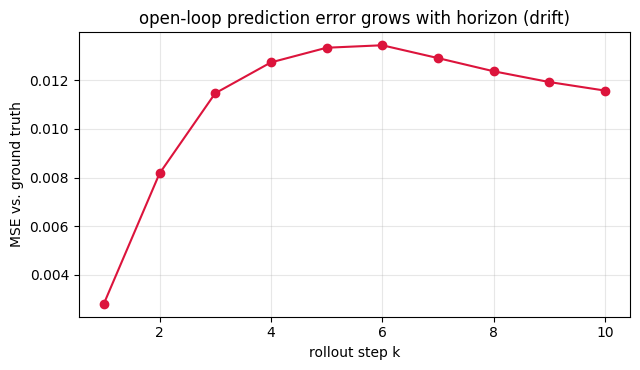

In [8]:
HORIZON = 10
n_eval = 64
starts_eval = rng.choice(valid[valid + HORIZON < len(imgs)], size=n_eval, replace=False)

err_per_step = np.zeros(HORIZON)
with torch.no_grad():
    z = enc(imgs[torch.from_numpy(starts_eval)])
    for k in range(HORIZON):
        a = acts[torch.from_numpy(starts_eval + k)]
        z = dyn(z, a)
        pred = torch.sigmoid(dec(z))[:, 0].numpy()
        truth = frames_np[starts_eval + k]
        err_per_step[k] = np.mean((pred - truth) ** 2)

plt.figure(figsize=(6.5, 3.8))
plt.plot(range(1, HORIZON + 1), err_per_step, "o-", color="crimson")
plt.xlabel("rollout step k")
plt.ylabel("MSE vs. ground truth")
plt.title("open-loop prediction error grows with horizon (drift)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Discussion: why does error accumulate — and what fixes it?

Every open-loop step has two error sources:

1. **Model error** — `dyn` is only approximately correct, so `z_k` drifts off the data manifold the decoder was trained on; once off-manifold, decoder errors explode too.
2. **No correction** — in an open loop there is *no measurement* to pull the belief back. Compare Lab 1: the Kalman filter's predict step also accumulates covariance, but every **update** step shrinks it again with a real observation.

That is exactly the design of the **RSSM** (Recurrent State-Space Model, PlaNet/Dreamer): a learned dynamics model for prediction *plus* a learned posterior that corrects the latent state with each new observation — a nonlinear, learned predict/update loop. Our tiny pipeline is the "predict-only" half of that story.

### ✏️ Exercise 1 — Latent dimension

Retrain with `Z_DIM = 4` and `Z_DIM = 64`. How do reconstruction quality and the drift curve change? What does the minimal sufficient dimension tell you about the intrinsic dimensionality of this world (position + velocity)?

**Hint:** you only need to rebuild `Encoder/Decoder/Dynamics` with a different `z_dim` and rerun Sections 3–7; the dataset cell is unchanged.

In [9]:
# YOUR CODE HERE
# hint: enc, dyn, dec = Encoder(z_dim=4), Dynamics(z_dim=4), Decoder(z_dim=4), then re-run the training cell
pass

### ✏️ Exercise 2 — Break the stop-gradient (on purpose)

Remove the two `detach()` calls in the training loop so the latent-prediction loss backpropagates into the encoder, and retrain. What happens to reconstruction quality? Can you explain the degenerate shortcut the model finds?

**Hint:** the latent-prediction loss hits ~zero almost immediately while reconstruction stalls — the encoder makes `z` temporally constant so the dynamics has nothing to predict. This is why self-predictive objectives always need a stop-gradient (or an EMA target network, as in BYOL).

In [10]:
# YOUR CODE HERE
# hint: change `z1_pred = dyn(z0.detach(), a)` to `z1_pred = dyn(z0, a)` and retrain
pass

### ✏️ Exercise 3 — Longer dreams

Push the rollout to 25 steps and plot the drift curve. At what horizon does the dream become useless for this world? Relate your answer to the ball's mixing time — how many steps until the trajectory "forgets" its initial condition anyway?

**Hint:** reuse the Section 7 code with `HORIZON = 25`; note that valid episode starts shrink, so use `valid[valid + HORIZON < len(imgs)]` as before.

In [11]:
# YOUR CODE HERE
pass

## Summary

- You trained a miniature learned world model end to end: **ConvEncoder (→ z ∈ R^16) → MLP dynamics (z_t, a_t) → ẑ_{t+1} → ConvDecoder**, with `reconstruction + 1-step latent prediction` loss, in minutes on CPU.
- One-step predictions decode to recognizable next frames; open-loop rollouts track the true trajectory for a few steps, then visibly drift.
- The drift curve quantifies **compounding model error without observation correction** — the precise motivation for posterior-corrected latent state-space models.
- Along the way you saw two practical lessons: sparse targets need loss reweighting (`pos_weight`), and self-predictive latent objectives need stop-gradient to avoid collapse.

**Next: Lab 3 — RSSM-style world models:** add stochastic latents and a learned posterior (the learned Kalman update), then imagine and plan in latent space.

*Course: World Models & Spatial Intelligence. Related: Ha & Schmidhuber (2018); Hafner et al. (2019) PlaNet & Dreamer; Watter et al. (2015) E2C.*